In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
df = pd.read_csv('./data/retailmax.csv')
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [3]:
features = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']]
features.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [4]:
scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)
scaled_features[0:3]

array([[-1.42456879, -1.73899919, -0.43480148],
       [-1.28103541, -1.73899919,  1.19570407],
       [-1.3528021 , -1.70082976, -1.71591298]])

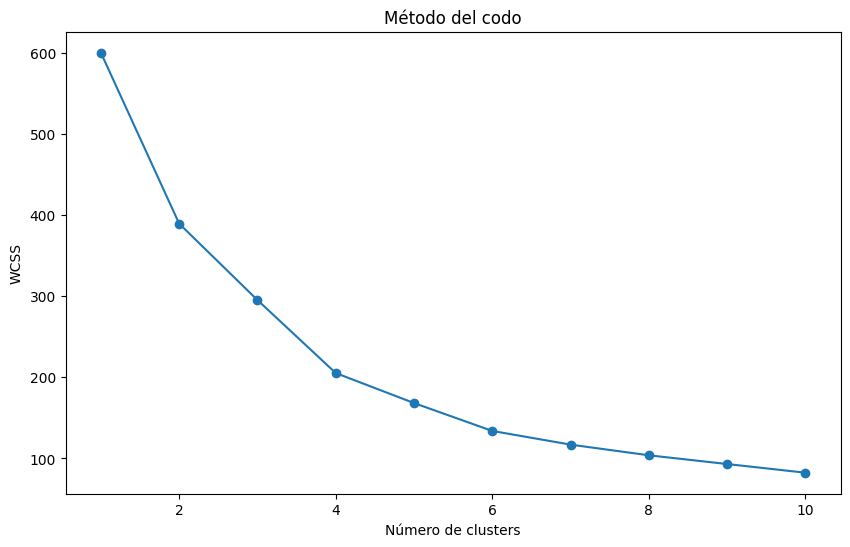

In [5]:
def calcular_wcss(datos):
    wcss = []
    for n in range(1, 11):
        kmeans = KMeans(n_clusters=n, init='k-means++', max_iter=300, n_init=10, random_state=42)
        kmeans.fit(datos)
        wcss.append(kmeans.inertia_)
    return wcss

wcss = calcular_wcss(scaled_features)

plt.figure(figsize=(10, 6))
plt.plot(range(1, 11), wcss, marker='o')
plt.title('Método del codo')
plt.xlabel('Número de clusters')
plt.ylabel('WCSS')
plt.show()

In [6]:
kmeans = KMeans(n_clusters=5, init='k-means++', max_iter=300, n_init=10, random_state=42)
clusters = kmeans.fit_predict(scaled_features)
df['Cluster'] = clusters
df.sample(5, random_state=42)

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
95,96,Male,24,60,52,1
15,16,Male,22,20,79,1
30,31,Male,60,30,4,0
158,159,Male,34,78,1,3
128,129,Male,59,71,11,3


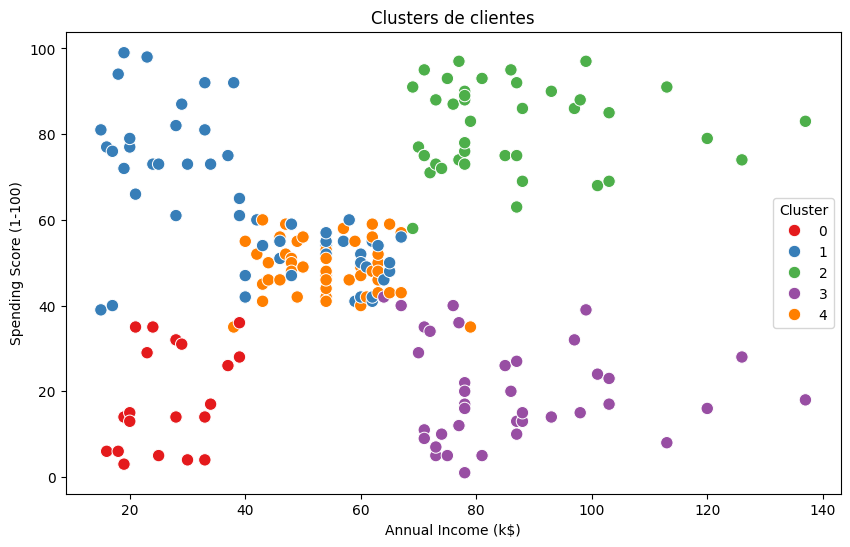

In [7]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', palette='Set1', s=80)
plt.title('Clusters de clientes')
plt.show()

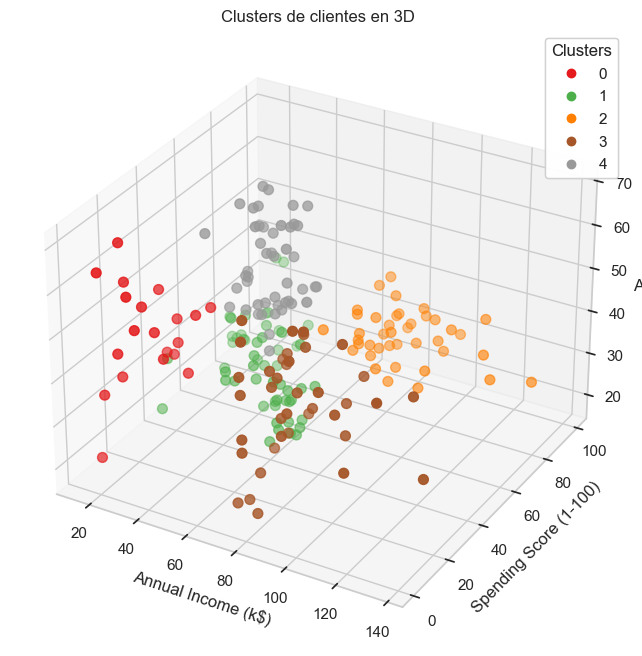

In [8]:
from mpl_toolkits.mplot3d import Axes3D

sns.set(style="whitegrid")
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'], df['Age'],
                      c=df['Cluster'], cmap='Set1', s=50)

ax.set_xlabel('Annual Income (k$)')
ax.set_ylabel('Spending Score (1-100)')
ax.set_zlabel('Age')
ax.set_title('Clusters de clientes en 3D')

legend1 = ax.legend(*scatter.legend_elements(), title="Clusters")
ax.add_artist(legend1)
plt.show()

In [9]:
cluster_analysis = df[['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Cluster']].groupby('Cluster').mean()
cluster_analysis

,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,46.250000,26.750000,18.350000
1,25.185185,41.092593,62.240741
2,32.875000,86.100000,81.525000
3,39.871795,86.102564,19.358974
4,55.638298,54.382979,48.851064


In [10]:
for cluster in cluster_analysis.index:
    print(f"Cluster {cluster}:")
    print(f" - Edad promedio: {cluster_analysis['Age'][cluster]:.2f}")
    print(f" - Ingreso anual promedio: {cluster_analysis['Annual Income (k$)'][cluster]:.2f}k$")
    print(f" - Spending Score promedio: {cluster_analysis['Spending Score (1-100)'][cluster]:.2f}")
    print("===========================================")

Cluster 0:
 - Edad promedio: 46.25
 - Ingreso anual promedio: 26.75k$
 - Spending Score promedio: 18.35
Cluster 1:
 - Edad promedio: 25.19
 - Ingreso anual promedio: 41.09k$
 - Spending Score promedio: 62.24
Cluster 2:
 - Edad promedio: 32.88
 - Ingreso anual promedio: 86.10k$
 - Spending Score promedio: 81.53
Cluster 3:
 - Edad promedio: 39.87
 - Ingreso anual promedio: 86.10k$
 - Spending Score promedio: 19.36
Cluster 4:
 - Edad promedio: 55.64
 - Ingreso anual promedio: 54.38k$
 - Spending Score promedio: 48.85
